In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

In [4]:
X, y = make_classification(n_samples=100, n_classes=2,n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(X, columns=["Col1", "col2", "col3", "col4", "col5"])
df["target"] = y
df.head()

,Col1,col2,col3,col4,col5,target
0,1.723836,3.219886,-0.827744,0.656255,3.039505,1
1,-0.771525,1.855956,0.901063,-0.300531,-1.958989,0
2,-0.757449,1.576154,-0.585572,1.781187,-0.081288,1
3,-1.185531,3.843418,1.608170,3.617666,0.233731,1
4,0.271096,2.008559,1.046425,1.431125,1.293473,1


In [6]:
df.shape

(100, 6)

### Now we wil create the fucntions for row sampling, column sampling and combined sampling

In [7]:
# function for row sampling
def row_sample(df, percent):
    new_df = df.sample(int(percent*df.shape[0]), replace=True)
    return new_df

In [9]:
row_sample(df, 0.2).shape

(20, 6)

In [46]:
# function for column sampling
import random
def col_sample(df, percent):
    new_df1 = random.sample(df.columns.to_list()[:-1] , int(percent*(df.shape[1] - 1)))
    new_df1 = df[new_df1]
    new_df1["target"] = df["target"]
    return  new_df1

In [49]:
col_sample(df, 0.8).shape, col_sample(df, 0.8).columns

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]
C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


((100, 5), Index(['col3', 'Col1', 'col2', 'col5', 'target'], dtype='object'))

In [16]:
df.columns.to_list()[:-1]

['Col1', 'col2', 'col3', 'col4', 'col5']

In [52]:
# function for combined sampling
def combined_sample(df, row_per, col_per):
    new_df = row_sample(df, row_per)
    return col_sample(new_df, col_per)

In [55]:
combined_sample(df, 0.2, 0.7).shape, combined_sample(df, 0.2, 0.7).columns

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]
C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


((20, 4), Index(['col5', 'Col1', 'col2', 'target'], dtype='object'))

### Now will train three decision trees and give differnt samples to three of them
#### first with row sampling

In [57]:
df1 = row_sample(df, 0.2)

In [58]:
df2 = row_sample(df, 0.2)

In [59]:
df3 = row_sample(df, 0.2)

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [64]:
clf1.fit(df1.iloc[:, 0:5], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, 0:5], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, 0:5], df3.iloc[:, -1])

DecisionTreeClassifier()

In [65]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[3] <= 0.238\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.4, 0.5, 'x[1] <= -0.842\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]')]

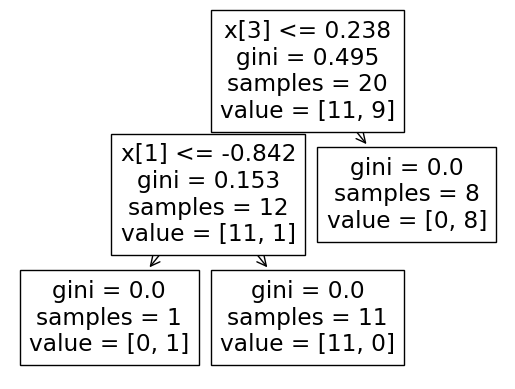

In [66]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[2] <= -0.94\ngini = 0.455\nsamples = 20\nvalue = [13, 7]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6, 0.5, 'x[3] <= 1.987\ngini = 0.133\nsamples = 14\nvalue = [13, 1]'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

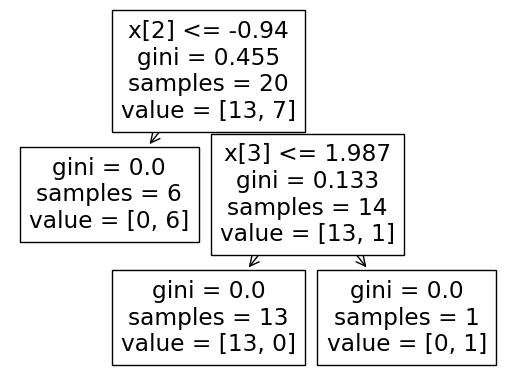

In [67]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[2] <= -0.465\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.4, 0.5, 'x[4] <= -2.128\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

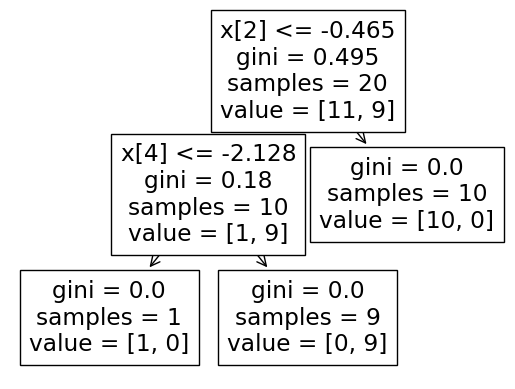

In [68]:
plot_tree(clf3)

In [69]:
df1.head()

,Col1,col2,col3,col4,col5,target
73,-2.601110,0.797757,-0.932342,1.070405,2.019938,1
66,-0.419963,3.579190,0.311360,-1.052331,-2.020859,0
1,-0.771525,1.855956,0.901063,-0.300531,-1.958989,0
74,-1.063203,1.436404,1.392909,-0.996545,-1.163932,0
46,-0.407783,-0.453469,-3.086663,0.118112,-2.870323,0


In [73]:
res1 = clf1.predict(np.array([-2.601110, 0.797757, -0.932342, 1.070405, 2.019938]).reshape(1, 5))
res1

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [74]:
res2 = clf2.predict(np.array([-2.601110, 0.797757, -0.932342, 1.070405, 2.019938]).reshape(1, 5))
res2

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [75]:
res3 = clf3.predict(np.array([-2.601110, 0.797757, -0.932342, 1.070405, 2.019938]).reshape(1, 5))
res3

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [85]:
res = [res1, res2, res3]
from scipy.stats import mode
mode(res)[0]

array([1], dtype=int64)

### Now we will do column sampling

In [86]:
df1 = col_sample(df, 0.6)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [87]:
df2 = col_sample(df, 0.6)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [88]:
df3 = col_sample(df, 0.6)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [90]:
df3.shape

(100, 4)

In [97]:
clf4 = DecisionTreeClassifier()
clf5 = DecisionTreeClassifier()
clf6 = DecisionTreeClassifier()

In [98]:
clf4.fit(df1.iloc[:,0:3], df1.iloc[:,-1])
clf5.fit(df2.iloc[:,0:3], df2.iloc[:,-1])
clf6.fit(df3.iloc[:,0:3], df3.iloc[:,-1])

DecisionTreeClassifier()

In [99]:
df3.head(2)

,col3,col4,col5,target
0,-0.827744,0.656255,3.039505,1
1,0.901063,-0.300531,-1.958989,0


In [100]:
res1 = clf4.predict(np.array([-0.827744, 0.656255, 3.039505]).reshape(1, 3))
res1

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [101]:
res2 = clf5.predict(np.array([-0.827744, 0.656255, 3.039505]).reshape(1, 3))
res2

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [102]:
res3 = clf5.predict(np.array([-0.827744, 0.656255, 3.039505]).reshape(1, 3))
res3

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [103]:
res = [res1, res2, res3]
from scipy.stats import mode
mode(res)[0]

array([1], dtype=int64)

### Now we will do combined sampling

In [104]:
df1 = combined_sample(df, 0.2, 0.8)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [105]:
df2 = combined_sample(df, 0.2, 0.8)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [106]:
df3 = combined_sample(df, 0.2, 0.8)

C:\Users\kumar\AppData\Local\Temp\ipykernel_12056\2211800279.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df1["target"] = df["target"]


In [107]:
df3.head()

,col3,col2,col4,col5,target
92,-2.343571,-2.045710,-1.018793,0.815531,1
34,-0.694308,2.856694,1.918869,-0.347242,1
72,1.080765,0.034148,1.942169,-1.454232,0
64,-1.211266,1.663749,0.909929,1.763253,1
30,-0.931884,-0.704351,0.534553,-0.363600,0


In [108]:
clf7 = DecisionTreeClassifier()
clf8 = DecisionTreeClassifier()
clf9 = DecisionTreeClassifier()

In [109]:
clf7.fit(df1.iloc[:, 0:4], df1.iloc[:,-1])
clf8.fit(df2.iloc[:, 0:4], df2.iloc[:,-1])
clf9.fit(df3.iloc[:, 0:4], df3.iloc[:,-1])

DecisionTreeClassifier()

In [110]:
res1 = clf7.predict(np.array([-1.211266, 1.663749, 0.909929, 1.763253]).reshape(1, 4))
res1

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [111]:
res2 = clf8.predict(np.array([-1.211266, 1.663749, 0.909929, 1.763253]).reshape(1, 4))
res2

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [112]:
res3 = clf9.predict(np.array([-1.211266, 1.663749, 0.909929, 1.763253]).reshape(1, 4))
res3

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [113]:
res = [res1, res2, res3]
from scipy.stats import mode
mode(res)[0]

array([1], dtype=int64)